# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Preparación

In [115]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns  
from pathlib import Path 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import time




# Cargar el dataset, por cuestiones de este sprint utilizo parse_dates para convertir la columna datetime de object a datetime directamente

ruta = Path('Data')/'taxi.csv'
df = pd.read_csv(ruta, parse_dates=['datetime'])

# Mostramos Informacion del dataset 
print(df.info())
display(df.describe())
display(df.sample(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    26496 non-null  datetime64[ns]
 1   num_orders  26496 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 414.1 KB
None


,datetime,num_orders
count,26496,26496.000000
mean,2018-05-31 23:55:00,14.070463
min,2018-03-01 00:00:00,0.000000
25%,2018-04-15 23:57:30,8.000000
50%,2018-05-31 23:55:00,13.000000
75%,2018-07-16 23:52:30,19.000000
max,2018-08-31 23:50:00,119.000000
std,NaN,9.211330


,datetime,num_orders
13304,2018-06-01 09:20:00,10
15193,2018-06-14 12:10:00,22
1724,2018-03-12 23:20:00,9
1249,2018-03-09 16:10:00,8
427,2018-03-03 23:10:00,2
16572,2018-06-24 02:00:00,22
2137,2018-03-15 20:10:00,9
11500,2018-05-19 20:40:00,12
16451,2018-06-23 05:50:00,5
2686,2018-03-19 15:40:00,4


In [116]:
# Quiero verficiar que no haya valores duplicados

duplicados = df.duplicated().sum()
display(f"Número de filas duplicadas: {duplicados}")

if duplicados > 0:
    df = df.drop_duplicates()

# Convertir num_orders a tipo float para un mejor uso para los modelos de ML

df['num_orders'] = df['num_orders'].astype('float')

# Establezco datetime como índice para facilitar el remuestreo

df = df.set_index('datetime')

# Remuestreo por hora, sumando los pedidos dentro de cada hora
df_hourly = df.resample('1h').sum()

# Vista previa del resultado
print(df_hourly.head())
print(df_hourly.info())

'Número de filas duplicadas: 0'

                     num_orders
datetime                       
2018-03-01 00:00:00       124.0
2018-03-01 01:00:00        85.0
2018-03-01 02:00:00        71.0
2018-03-01 03:00:00        66.0
2018-03-01 04:00:00        43.0
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   num_orders  4416 non-null   float64
dtypes: float64(1)
memory usage: 69.0 KB
None


Notas:

Hasta este punto todos los datos estan limpios para poder trabajar con ellos 

Se uso resample para que haya una sola fila por hora, con la suma de los pedidos de taxi en esa hora. sera importante mas adelante.
De igual manera se hizo el cambio de int a float ya que es mas util para modelos de regresión.

## Análisis

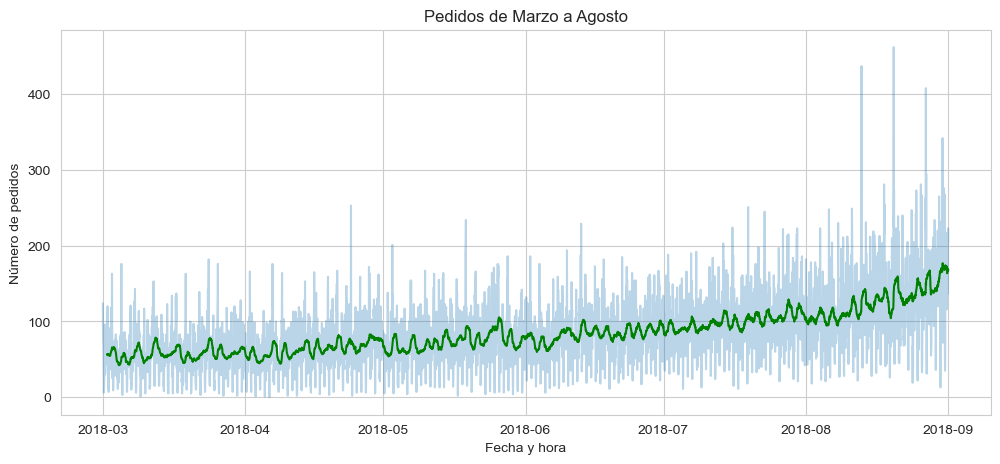

In [117]:
# Necesitamos generar un grafico para visualizar por hora durante los meses de Marzo a Agosto

df_hourly['num_orders_smooth'] = df_hourly['num_orders'].rolling(window=24).mean()  # Promedio móvil 24 horas
plt.figure(figsize=(12,5))
plt.plot(df_hourly.index, df_hourly['num_orders'], alpha=0.3)
plt.plot(df_hourly.index, df_hourly['num_orders_smooth'], color='green')
plt.title('Pedidos de Marzo a Agosto')
plt.xlabel('Fecha y hora')
plt.ylabel('Número de pedidos')
plt.grid(True)
plt.show()


Con esta grafica me doy cuenta el incremento en numero de pedido de Julio a los ultimos dias de Agosto y no solo en numero de pedidos por dia y hora si no que tambien la media aumento, deberiamos revisar que es lo que esta pasando y porque estan esos incrementos.

Mi respuesta por el momento puede deberse a periodos vacacionales y por eso se utilizan mas los servicios de taxi para los aeropuertos.

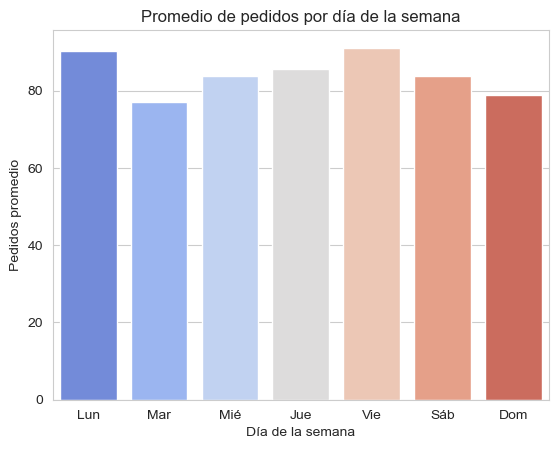

In [118]:
# Genero una grafica para entener el promedio de los pedidos por dia de la semana.
df_plot = promedio_por_dia.reset_index()
df_plot.columns = ['day', 'avg_orders']

sns.barplot(data=df_plot, x='day', y='avg_orders', hue='day', dodge=False, palette='coolwarm', legend=False)
plt.title('Promedio de pedidos por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Pedidos promedio')
plt.legend([],[], frameon=False)  # Ocultar leyenda
plt.show()



 Quice utiliza rl el promedio ya que muestra la cantidad típica de pedidos que se reciben en un solo lunes (igual para otros días). Es una mejor forma de entender el comportamiento de cada día.

 Por lo que muestra la grafica los dias Lunes y viernes son los dias mas solicitados de toda la semana.

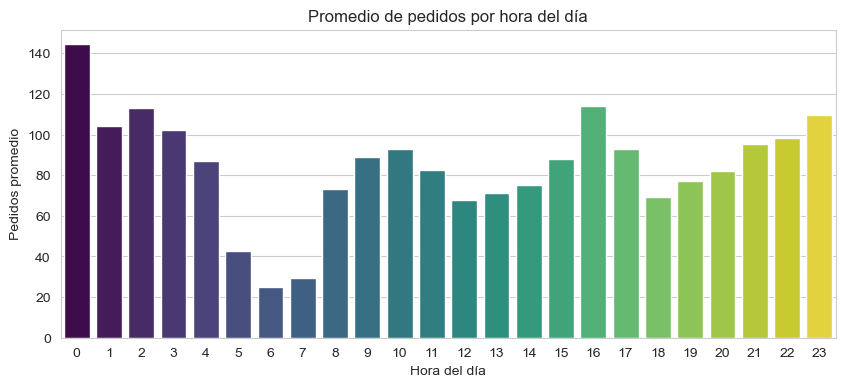

In [119]:
# Gener un grafico para entendee el promedio de peddios por hora del dia he identificar la hora pico
df_plot = promedio_por_hora.reset_index()
df_plot.columns = ['hour', 'avg_orders']

sns.set_style('whitegrid')
plt.figure(figsize=(10,4))
sns.barplot(data=df_plot, x='hour', y='avg_orders', hue='hour', dodge=False, palette='viridis', legend=False)
plt.title('Promedio de pedidos por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Pedidos promedio')
plt.show()





De igual manera que con la grafica anterior busco identificar patrones, las tendencias y las horas picos de los servicios y de hecho esta es
muy interesante por que vemos que nuestra hora 0 o 24 como prefieras verlo tiene el punto mas alto puede deberse a que los vuelos mas 
economicos son en la madrugada, por lo cual las personas utilizan mas este servicio.

De igual manera cada vez he buscado hacer graficas un poco mas especificas oara identificar patrones temporales clave en la demanda de taxis.

Serie de tiempo general: muestra la evolución de pedidos a lo largo de los meses, útil para detectar tendencias y anomalías.

Promedio por día de la semana: ayuda a identificar variaciones semanales y comportamientos distintos entre días laborales y fines de semana.

Promedio por hora del día: revela las horas pico y los momentos de menor demanda cada día.



## Formación

#### Regresion Lineal 


In [120]:
df_features = df_hourly.copy()

df_features['hour'] = df_features.index.hour
df_features['dayofweek'] = df_features.index.dayofweek
df_features['month'] = df_features.index.month

df_features['num_orders_smooth'] = df_features['num_orders'].rolling(window=24).mean()

# Eliminar filas con NaN (probablemente las primeras 23 filas)
df_features = df_features.dropna()

target = df_features['num_orders']
features = df_features.drop(columns=['num_orders'])

features = pd.get_dummies(features, drop_first=True)


# Seleccionamos los parametros para entrenar nuestro modelo en 25% prueba y 75% entrenamiento
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.25, random_state=42)

print(features.isna().sum())

num_orders_smooth    0
hour                 0
dayofweek            0
month                0
dtype: int64


In [121]:

# Medir tiempo de entrenamiento (práctica)
start_train = time.time()

model_lr = LinearRegression()  # Creo el modelo de regresión lineal
model_lr.fit(features_train, target_train)  # Entreno el modelo

end_train = time.time()
train_time_lr = end_train - start_train  # Tiempo de entrenamiento

# Medir tiempo de predicción
start_pred = time.time()

predictions_lr = model_lr.predict(features_test)  # Predicciones con datos de prueba

end_pred = time.time()
predict_time_lr = end_pred - start_pred  # Tiempo de predicción

# Calcular RMSE (Root Mean Squared Error)
rmse = root_mean_squared_error(target_test, predictions_lr)
print(f"RMSE del modelo de Regresión Lineal: {rmse:.2f}")

# Calcular RMSE relativo en porcentaje para entender el error relativo
mean_orders = target_train.mean()  # mejor usar la media del set de entrenamiento

rmse_percent = (rmse / mean_orders) * 100
print(f"RMSE relativo: {rmse_percent:.2f}%")

print(f"Tiempo de entrenamiento: {train_time_lr:.2f} segundos")
print(f"Tiempo de predicción: {predict_time_lr:.2f} segundos")


RMSE del modelo de Regresión Lineal: 36.34
RMSE relativo: 43.03%
Tiempo de entrenamiento: 0.00 segundos
Tiempo de predicción: 0.00 segundos


Notas :

RMSE = 36.34 significa que en promedio tu modelo se equivoca por unos 36 pedidos por hora, en la escala original.

RMSE relativo = 43.03% indica que ese error es aproximadamente un 43% de la media de pedidos, o sea, un error relativo que te ayuda a dimensionar qué tan lejos está el modelo.

Los tiempos de entrenamiento y predicción son muy bajos, lo cual es ideal.

#### Random Forest

In [122]:
# Crear y entrenar el modelo
start_train = time.time()

model_rf = RandomForestRegressor(random_state=42, n_estimators=100)  # 100 árboles por defecto
model_rf.fit(features_train, target_train)

end_train = time.time()
train_time_rf = end_train - start_train

# Hacer predicciones
start_pred = time.time()

predictions_rf = model_rf.predict(features_test)

end_pred = time.time()
predict_time_rf = end_pred - start_pred

# Calcular RMSE y RMSE relativo
rmse_rf = root_mean_squared_error(target_test, predictions_rf)
rmse_percent_rf = (rmse_rf / target_train.mean()) * 100

print(f"RMSE del Random Forest: {rmse_rf:.2f}")
print(f"RMSE relativo: {rmse_percent_rf:.2f}%")
print(f"Tiempo de entrenamiento: {train_time_rf:.2f} segundos")
print(f"Tiempo de predicción: {predict_time_rf:.2f} segundos")

RMSE del Random Forest: 22.89
RMSE relativo: 27.10%
Tiempo de entrenamiento: 1.36 segundos
Tiempo de predicción: 0.04 segundos


Con ese RMSE absoluto de 22.89 y un RMSE relativo del 27.10%, el Random Forest mejoró bastante respecto a la regresión lineal, además de mantener un tiempo de predicción muy rápido.

Ahora tienes una buena base para comparar con otros modelos o ajustar hiperparámetros si quieres sacarle aún más jugo.

#### LightGBM

In [123]:
# Crear dataset para LightGBM
train_data = lgb.Dataset(features_train, label=target_train)
test_data = lgb.Dataset(features_test, label=target_test)

# Definir parámetros básicos
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'random_state': 42
}

# Medir tiempo de entrenamiento
start_train = time.time()

# Entrenar el modelo
model_lgb = lgb.train(params, train_data, num_boost_round=100)

end_train = time.time()
train_time_lgb = end_train - start_train

# Medir tiempo de predicción
start_pred = time.time()

predictions_lgb = model_lgb.predict(features_test)

end_pred = time.time()
predict_time_lgb = end_pred - start_pred

# Calcular RMSE
rmse_lgb =root_mean_squared_error(target_test, predictions_lgb)
print(f"RMSE del LightGBM: {rmse_lgb:.2f}")

# RMSE relativo
rmse_percent_lgb = (rmse_lgb / target_train.mean()) * 100
print(f"RMSE relativo: {rmse_percent_lgb:.2f}%")

print(f"Tiempo de entrenamiento: {train_time_lgb:.2f} segundos")
print(f"Tiempo de predicción: {predict_time_lgb:.2f} segundos")

RMSE del LightGBM: 21.97
RMSE relativo: 26.02%
Tiempo de entrenamiento: 0.17 segundos
Tiempo de predicción: 0.00 segundos


RMSE 21.97 (y relativo 26%) indica que el modelo LightGBM tiene buen ajuste.

Además, el tiempo de entrenamiento y predicción es muy rápido, ideal para producción.

Regresión Lineal (más básico)

Random Forest (más complejo y mejor resultado)

LightGBM (rápido y con mejor performance que Random Forest)

## Prueba

# Lista de revisión

- [x]  	
Jupyter Notebook está abierto.
- [ ]  El código no tiene errores
- [ ]  Las celdas con el código han sido colocadas en el orden de ejecución.
- [ ]  	
Los datos han sido descargados y preparados.
- [ ]  Se ha realizado el paso 2: los datos han sido analizados
- [ ]  Se entrenó el modelo y se seleccionaron los hiperparámetros
- [ ]  Se han evaluado los modelos. Se expuso una conclusión
- [ ] La *RECM* para el conjunto de prueba no es más de 48